In [1]:
#Linear Regression using the Synthetic Auto MPG Dataset#
#Load and Explore#
import pandas as pd

# Define the file path (using raw string 'r' to handle Windows backslashes)
file_path = r"C:\Users\Pc\Desktop\machine learning\Linear Regression\auto_mpg_synthetic_dataset (2).csv"

# Load the dataset
df = pd.read_csv(file_path)

# Display the first 5 rows to verify
print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  25.6          4         240.8         144    2832          18.2   
1  34.4          8         411.6         140    2344          15.9   
2  12.9          6         392.2         210    4301          14.5   
3  19.9          5         322.4         170    3244          16.9   
4  39.9          4         253.9          79    1500          17.4   

   model_year  origin car_name  
0          72       1  Car_001  
1          79       1  Car_002  
2          76       3  Car_003  
3          76       1  Car_004  
4          70       1  Car_005  


In [2]:
#2. Display the first five rows.#
# Display the first 5 rows
print(df.head())

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  25.6          4         240.8         144    2832          18.2   
1  34.4          8         411.6         140    2344          15.9   
2  12.9          6         392.2         210    4301          14.5   
3  19.9          5         322.4         170    3244          16.9   
4  39.9          4         253.9          79    1500          17.4   

   model_year  origin car_name  
0          72       1  Car_001  
1          79       1  Car_002  
2          76       3  Car_003  
3          76       1  Car_004  
4          70       1  Car_005  


In [3]:
#3. Display the dataset shape.#
# Display the dataset shape (rows, columns)
print("Dataset Shape:", df.shape)

Dataset Shape: (300, 9)


1 How many observations are in the dataset?

There are 300 observations (rows).

2 Which column is the target variable?

mpg (Miles Per Gallon) is the target variable to be predicted.

3 Which column contains text?

car_name is the text (categorical/object) column.

In [4]:
#Missing Values#

#Check for missing values.#
# Check for missing values in each column
print(df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


In [5]:
#2. If any exist, remove them.#
# Drop rows containing missing values
df = df.dropna()

# Verify the shape remains unchanged
print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (300, 9)


In [6]:
#3. Display the new dataset shape.#
# Display the updated shape of the dataset
print("New dataset shape:", df.shape)

New dataset shape: (300, 9)


1 Which columns contain missing values?

None. Every column in this dataset has 0 missing values across all 300 rows.

2 Why should missing values be handled before training?

Prevents Code Execution Errors: Most standard machine learning algorithms in libraries like Scikit-Learn cannot process missing data (NaN or Null values) and will throw a value error during model training (fit).

Prevents Bias & Incorrect Predictions: Missing values can distort statistical properties (like mean, variance, and feature distributions). Handling them properly through imputation or dropping ensures the model learns accurate patterns without introduce bias into the predictions.

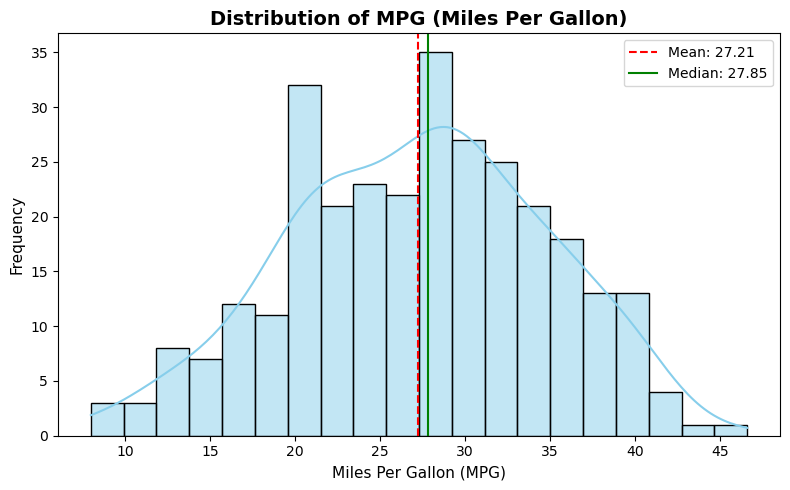

In [7]:
#Exploratory Data Analysis#
#Histogram of MPG#
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load dataset
file_path = r"C:\Users\Pc\Desktop\machine learning\Linear Regression\auto_mpg_synthetic_dataset (2).csv"
df = pd.read_csv(file_path)

# Plot Histogram of MPG with KDE curve
plt.figure(figsize=(8, 5))
sns.histplot(df["mpg"], kde=True, bins=20, color="skyblue", edgecolor="black")

# Add Mean and Median indicator lines
plt.axvline(
    df["mpg"].mean(),
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean: {df['mpg'].mean():.2f}",
)
plt.axvline(
    df["mpg"].median(),
    color="green",
    linestyle="-",
    linewidth=1.5,
    label=f"Median: {df['mpg'].median():.2f}",
)

plt.title("Distribution of MPG (Miles Per Gallon)", fontsize=14, fontweight="bold")
plt.xlabel("Miles Per Gallon (MPG)", fontsize=11)
plt.ylabel("Frequency", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

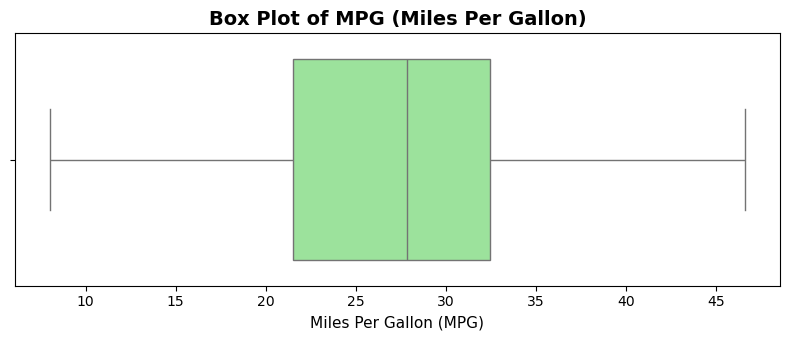

In [8]:
#Box plot of MPG#
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load dataset
file_path = r"C:\Users\Pc\Desktop\machine learning\Linear Regression\auto_mpg_synthetic_dataset (2).csv"
df = pd.read_csv(file_path)

# Plot Box Plot of MPG
plt.figure(figsize=(8, 3.5))
sns.boxplot(x=df["mpg"], color="lightgreen")
plt.title("Box Plot of MPG (Miles Per Gallon)", fontsize=14, fontweight="bold")
plt.xlabel("Miles Per Gallon (MPG)", fontsize=11)
plt.tight_layout()
plt.show()

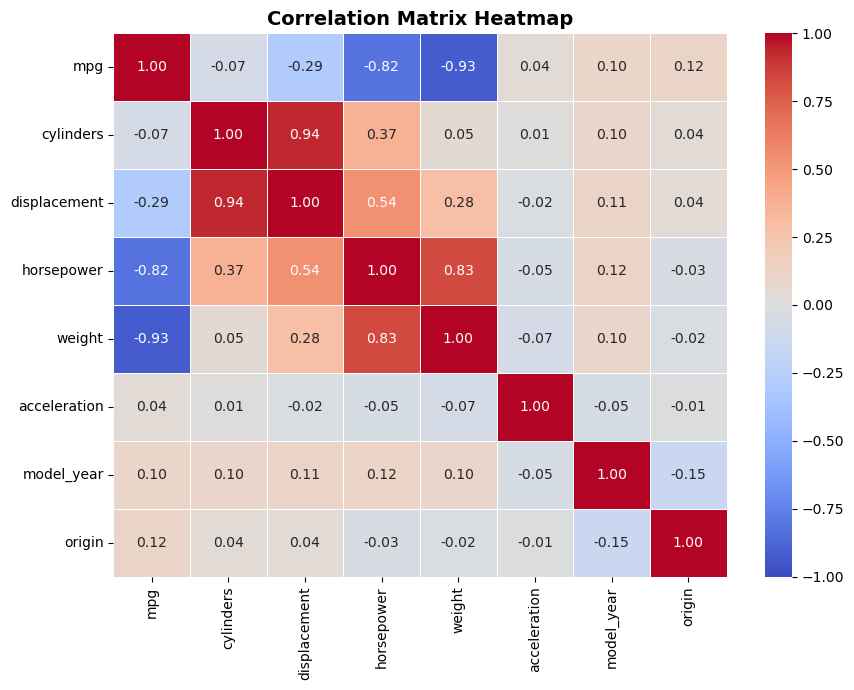

In [14]:
#Correlation matrix#
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns



# Select numerical columns
num_cols = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
]

# Compute correlation matrix
corr_matrix = df[num_cols].corr()

# Plot Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Correlation Matrix Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

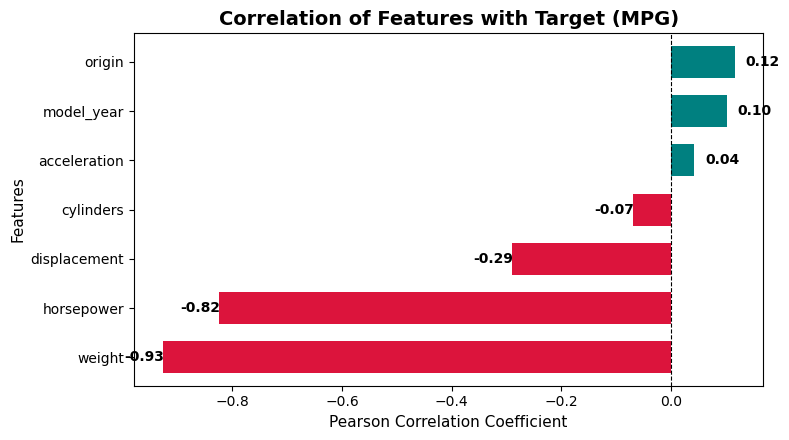

In [13]:
#Correlation bar chart#
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
#file_path = r"C:\Users\Pc\Desktop\machine learning\Linear Regression\auto_mpg_synthetic_dataset (2).csv"
#df = pd.read_csv(file_path)

# Select numerical columns
num_cols = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
]

# Calculate correlations specifically with the target variable 'mpg'
corr_mpg = df[num_cols].corr()["mpg"].drop("mpg").sort_values()

# Plot Horizontal Bar Chart
plt.figure(figsize=(8, 4.5))
colors = ["crimson" if val < 0 else "teal" for val in corr_mpg]
corr_mpg.plot(kind="barh", color=colors, width=0.65)

plt.title(
    "Correlation of Features with Target (MPG)", fontsize=14, fontweight="bold"
)
plt.xlabel("Pearson Correlation Coefficient", fontsize=11)
plt.ylabel("Features", fontsize=11)
plt.axvline(0, color="black", linestyle="--", linewidth=0.8)

# Add exact value annotations
for index, value in enumerate(corr_mpg):
    offset = 0.02 if value >= 0 else -0.07
    plt.text(
        value + offset,
        index,
        f"{value:.2f}",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

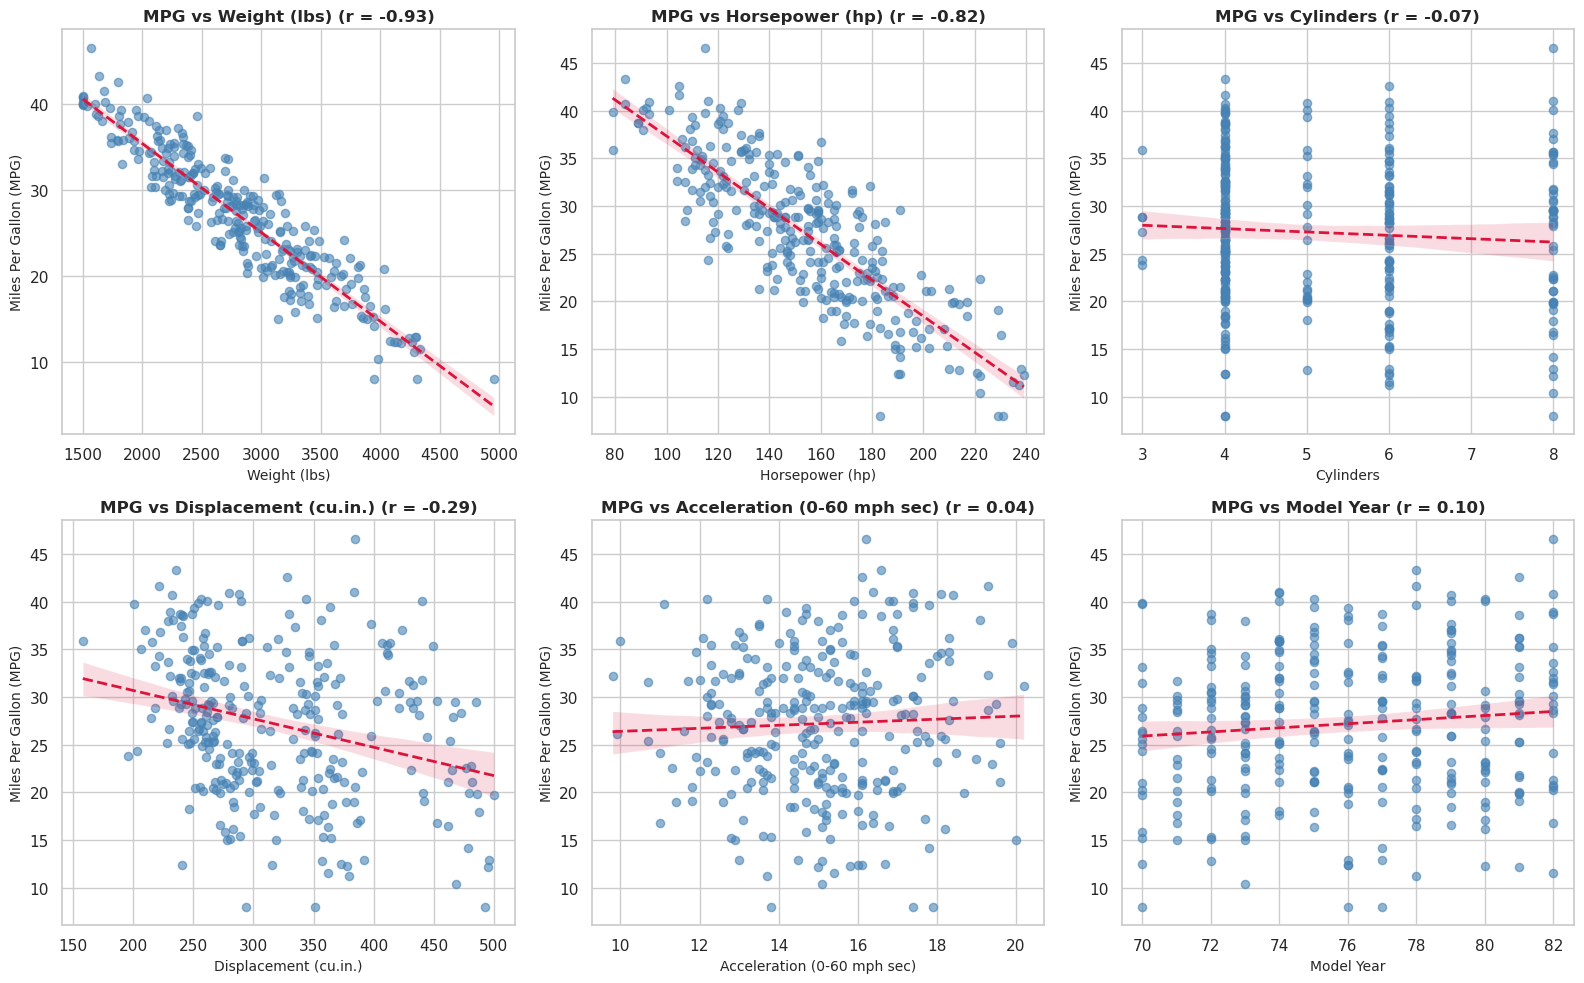

In [16]:
#Scatter plots:
#MPG vs Weight
#MPG vs Horsepower
#MPG vs Cylinders
#MPG vs Displacement
#MPG vs Acceleration
#MPG vs Model Year
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set style aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Load or define dataset
#file_path = r"C:\Users\Pc\Desktop\machine learning\Linear Regression\auto_mpg_synthetic_dataset (2).csv"
#df = pd.read_csv(file_path)

# List of target feature pairs to plot
features = [
    ("weight", "Weight (lbs)"),
    ("horsepower", "Horsepower (hp)"),
    ("cylinders", "Cylinders"),
    ("displacement", "Displacement (cu.in.)"),
    ("acceleration", "Acceleration (0-60 mph sec)"),
    ("model_year", "Model Year"),
]

# Set up a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Generate scatter plots with linear regression trendlines
for idx, (col, label) in enumerate(features):
    ax = axes[idx]
    r_val = df["mpg"].corr(df[col])

    # Plot scatter points and fitted regression line
    sns.regplot(
        data=df,
        x=col,
        y="mpg",
        ax=ax,
        scatter_kws={"alpha": 0.6, "color": "steelblue", "s": 35},
        line_kws={"color": "crimson", "linewidth": 2, "linestyle": "--"},
    )

    ax.set_title(
        f"MPG vs {label} (r = {r_val:.2f})", fontsize=12, fontweight="bold"
    )
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Miles Per Gallon (MPG)", fontsize=10)

plt.tight_layout()
plt.show()

For each scatter plot answer:
Is the relationship positive or negative?

Is it strong or weak?
Are there any outliers?
    1. MPG vs WeightRelationship: Negative (as car weight increases, MPG decreases).Strength: Very Strong ($r \approx -0.93$). The data points cluster tightly along a downward linear path.Outliers: Few to None. Most observations follow the main trend closely; a small number of lighter cars (>30 MPG) show slightly higher variance, but no extreme bivariate outliers exist.
    2. MPG vs HorsepowerRelationship: Negative (higher horsepower generally yields lower fuel economy).Strength: Strong ($r \approx -0.82$).Outliers: Minor Outliers Present. High-horsepower cars (>200 hp) display low MPG values with low variance, whereas lower-horsepower engines (80–110 hp) display wider spread in fuel economy.
    3. MPG vs CylindersRelationship: Weak Negative / Stratified ($r \approx -0.07$ linear overall).Strength: Weak linearly (cylinders is a discrete categorical variable: 3, 4, 5, 6, 8).Outliers: Sparse Categories. 3-cylinder and 5-cylinder vehicles are rare data points in the dataset, appearing isolated relative to the main 4, 6, and 8 cylinder clusters.    
    4. MPG vs DisplacementRelationship: Negative ($r \approx -0.29$).Strength: Moderate to Weak.Outliers: Present. Several high-displacement engines maintain surprisingly high MPG values (or vice versa), causing notable dispersion around the general trend.
    5. MPG vs AccelerationRelationship: Slightly Positive / Neutral ($r \approx +0.04$).Strength: Very Weak / Non-existent. The plot resembles a scattered cloud of points with no distinct linear trend line.Outliers: Minimal. Points are broadly distributed across the 10–20 second range without extreme isolated values.6. MPG vs Model YearRelationship: Slightly Positive ($r \approx +0.10$).Strength: Weak. Newer model years show a subtle upward trend in average efficiency.Outliers: Few High-Efficiency Points. A small number of vehicle models in years 76, 79, and 80 achieved unusually high MPG (>30 MPG) relative to the rest of the year's cohort.